In [1]:
!pip install lime xgboost scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b3ef0797a6e107e388790e0d46907b30f71fe39fcdd96a62ff665289d9b3f6d0
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import pickle
from lime.lime_tabular import LimeTabularExplainer


In [4]:
df = pd.read_csv("/content/drive/MyDrive/final_dataset_with_y.csv")

print(df.shape)
df.head()


(48686, 41)


,repo_name,is_fork,fork_owner_type,created_at,total_commits,commit_frequency_per_week,unique_commit_authors,issues_opened,issues_closed,issue_close_rate,...,parent_stars,parent_forks,parent_created_at,parent_language,early_commits_on_branch,parent_early_commits,divergence_ratio,primary_language,topics,is_sustainable
0,eowyncim/snarkOS,True,User,2023-12-04 17:02:26+00:00,0,0.000000,0,0,0,NaN,...,4509.0,2682.0,2020-02-16T21:46:21Z,Rust,0.0,1093.0,0.0,Rust,NaN,0
1,sumitpatro143/minimal,True,User,2024-01-03 00:57:14+00:00,1,0.038462,1,0,0,NaN,...,1780.0,6394.0,2016-10-06T23:07:49Z,SCSS,5.0,5.0,0.5,SCSS,NaN,0
2,olduma/layout_product-cards,True,User,2024-01-31 07:35:47+00:00,1,0.038462,1,0,0,NaN,...,20.0,5417.0,2019-04-24T12:05:45Z,JavaScript,0.0,13.0,0.0,JavaScript,NaN,0
3,crucial-keydev/Spoon-Knife,True,User,2024-01-23 20:40:25+00:00,0,0.000000,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,nanimonii/hello-uniapp,True,User,2023-12-11 07:54:24+00:00,0,0.000000,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [5]:
y = df['is_sustainable']

X = df.drop(columns=[
    'is_sustainable',
    'repo_name',
    'created_at',
    'parent_created_at',
    'topics',
    'parent_repo'
])
print(X.shape)



(48686, 35)


In [6]:
numerical_cols = X.select_dtypes(include=['number']).columns
categorical_cols = X.select_dtypes(include=['object','bool']).columns


In [7]:
for col in numerical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mode()[0])


for col in X.select_dtypes(include=['bool']).columns:
    X[col] = X[col].astype(int)



/tmp/ipykernel_201/26268817.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].fillna(X[col].mode()[0])


In [8]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(X.shape)


(48686, 502)


In [9]:
with open("/content/drive/MyDrive/new_xgboost_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [10]:
X_sample = X.sample(1000, random_state=42)

explainer = LimeTabularExplainer(
    training_data=X_sample.values,
    feature_names=X.columns.tolist(),
    class_names=["Not Sustainable","Sustainable"],
    mode="classification"
)

print("LIME explainer ready.")


LIME explainer ready.


In [14]:
from collections import defaultdict
import numpy as np

positive_counts = defaultdict(int)
negative_counts = defaultdict(int)

sample_indices = np.random.choice(len(X), 100, replace=False)

for i in sample_indices:

    exp = explainer.explain_instance(
        X.values[i],
        loaded_model.predict_proba,
        num_features=10,
        num_samples=1000
    )

    for feature, weight in exp.as_list():

        feature_name = feature.split(" <= ")[0]   # clean feature name

        if weight > 0:
            positive_counts[feature_name] += 1
        else:
            negative_counts[feature_name] += 1


In [15]:
features = set(list(positive_counts.keys()) + list(negative_counts.keys()))

rows = []

for f in features:

    pos = positive_counts[f]
    neg = negative_counts[f]
    total = pos + neg

    rows.append({
        "Feature": f,
        "Positive_Count": pos,
        "Negative_Count": neg,
        "Total": total,
        "Positive_%": pos / total if total > 0 else 0,
        "Negative_%": neg / total if total > 0 else 0
    })

direction_table = pd.DataFrame(rows)
direction_table = direction_table.sort_values(
    "Total",
    ascending=False
)

direction_table.head(20)

,Feature,Positive_Count,Negative_Count,Total,Positive_%,Negative_%
58,early_commits_on_branch,0,45,45,0.000000,1.000000
60,parent_language_R,9,11,20,0.450000,0.550000
78,parent_language_Nim,15,5,20,0.750000,0.250000
2,parent_language_Swift,5,13,18,0.277778,0.722222
89,parent_language_XS,6,12,18,0.333333,0.666667
11,total_pr_comments,12,6,18,0.666667,0.333333
69,primary_language_R,18,0,18,1.000000,0.000000
59,parent_language_Lua,8,9,17,0.470588,0.529412
79,parent_language_Cairo,11,6,17,0.647059,0.352941
82,primary_language_GLSL,8,9,17,0.470588,0.529412


In [16]:
#Run this code block to generate positive VS Negative Influence of LIME (1)

features = set(list(positive_counts.keys()) + list(negative_counts.keys()))

rows = []

for f in features:

    pos = positive_counts[f]
    neg = negative_counts[f]
    total = pos + neg

    rows.append({
        "Feature": f,
        "Positive_Count": pos,
        "Negative_Count": neg,
        "Total": total,
        "Positive_%": pos / total if total > 0 else 0,
        "Negative_%": neg / total if total > 0 else 0
    })

direction_table = pd.DataFrame(rows)


In [17]:
#Run this code block to generate positive VS Negative Influence of LIME (2)

direction_table.to_csv("lime_feature_direction.csv", index=False)

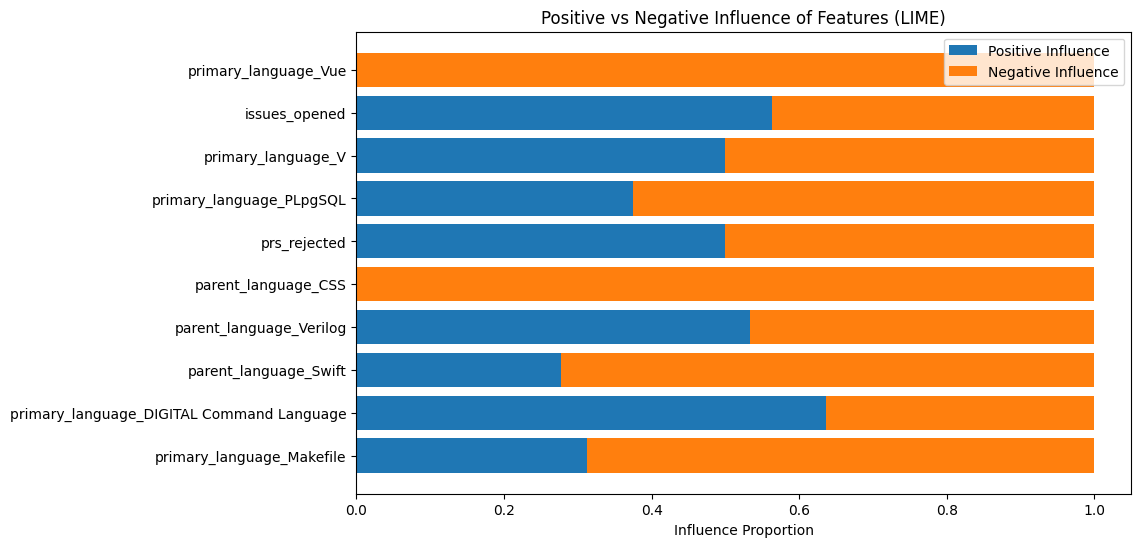

In [18]:
#Run this code block to generate positive VS Negative Influence of LIME (3)
import matplotlib.pyplot as plt

top10 = direction_table.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Positive_%"], label="Positive Influence")
plt.barh(top10["Feature"], top10["Negative_%"], left=top10["Positive_%"], label="Negative Influence")

plt.xlabel("Influence Proportion")
plt.title("Positive vs Negative Influence of Features (LIME)")
plt.legend()

plt.show()

In [ ]:
#run this code block instead to generate the aggregated LIME analysis ranking of features (1)
from collections import defaultdict
import numpy as np

importance = defaultdict(float)

X_values = X.values
sample_indices = np.random.choice(len(X_values), 50, replace=False)

for i in sample_indices:

    exp = explainer.explain_instance(
        X_values[i],
        loaded_model.predict_proba,
        num_features=10,
        num_samples=1000
    )

    for feature, weight in exp.as_list():
        importance[feature] += abs(weight)

In [ ]:
#run this code block instead to generate the aggregated LIME analysis ranking of features (1)

for feature in importance:
    importance[feature] /= len(sample_indices)

sorted_importance = sorted(
    importance.items(),
    key=lambda x: x[1],
    reverse=True
)

sorted_importance[:20]


In [ ]:
#run this code block instead to generate the aggregated LIME analysis ranking of features (1)

clean_importance = {}

for feature, weight in sorted_importance:
    name = feature.split(" <= ")[0]
    clean_importance[name] = weight

sorted(clean_importance.items(), key=lambda x: x[1], reverse=True)[:20]


In [ ]:
#run this code block instead to generate the aggregated LIME analysis ranking of features (1)

import pandas as pd

lime_ranked = pd.DataFrame(
    sorted(clean_importance.items(), key=lambda x: x[1], reverse=True),
    columns=["Feature", "Avg_LIME_Importance"]
)

lime_ranked.insert(0, "Rank", range(1, len(lime_ranked) + 1))

lime_ranked.head(20)
